# Current-Status HAL-MLE Experiments

This notebook isolates all current-status (CS) analysis from `examples/example_ic_FISTA.ipynb`.

It includes:
- CS data generation
- PGD and FISTA fits/tuning
- Optimization diagnostics
- CV landscape vs L1 constraint `M`
- CV landscape vs FISTA penalty `lambda`
- Local-vs-global proxy analysis via multi-restarts

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold

from haldensity.censoring import (
    IntervalCensoredFISTAEstimator,
    IntervalCensoredFISTATuner,
    IntervalCensoredProjectedGDEstimator,
    IntervalCensoredProjectedGDTuner,
    interval_censor_current_status_uniform,
    kl_divergence,
)
from haldensity.censoring.interval.metrics import incomplete_loglik_interval
from haldensity.utils import TruncatedGMM

np.random.seed(42)

/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Simulate latent event times on [0, 1]
components = [
    {"mean": 0.30, "std": 0.08, "lower": 0.0, "upper": 1.0},
    {"mean": 0.72, "std": 0.06, "lower": 0.0, "upper": 1.0},
]
weights = [0.55, 0.45]
sampler = TruncatedGMM(components=components, weights=weights)

# Smaller sample size for faster experimentation
n = 200
t_event = sampler.generate_samples(n)

# Build current-status data from the same latent event-time distribution
cs_df = interval_censor_current_status_uniform(t_event, random_state=7)
cs_df.head()

,L,R
0,0.000000,0.625095
1,0.000000,0.897214
2,0.000000,0.775686
3,0.225207,1.000000
4,0.300166,1.000000


Best trial: 24. Best value: 16.2516: 100%|██████████| 30/30 [00:21<00:00,  1.39it/s]


Current-status PGD best params: {'basis_order': 2, 'norm_constraint': 10.435109827473802}
Current-status FISTA best params: {'basis_order': 1, 'lam': 0.019919137715298973}


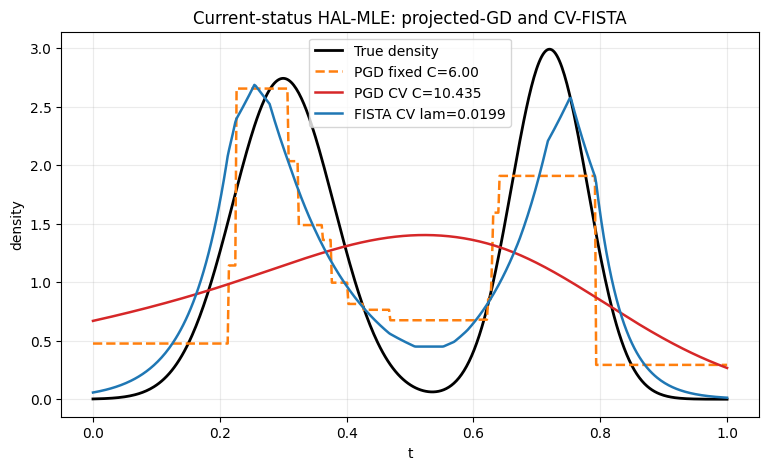

,model,value,KL(true || estimated)
0,PGD fixed C,6.000000,0.186735
1,PGD CV C,10.435110,0.453148
2,FISTA CV lam,0.019919,0.081172


In [3]:
# Fixed projected-GD model on current-status
cs_fixed_nc = 6.0
pgd_cs_fixed = IntervalCensoredProjectedGDEstimator(
    norm_constraint=cs_fixed_nc,
    learning_rate=0.05,
    use_nesterov=True,
    n_iterations=2000,
    tol=1e-6,
    ll_change_tol=1e-3,
    n_grid_points=300,
    basis_order=0,
)
pgd_cs_fixed.fit(cs_df, knot_strategy="turnbull")

# CV-tuned projected-GD model on current-status
pgd_cs_tuner = IntervalCensoredProjectedGDTuner(
    data=cs_df,
    cv_folds=5,
    random_state=7,
    n_grid_points=260,
    param_overrides={
        "basis_order": [0, 1, 2],
        "norm_constraint": {"low": 1.0, "high": 20.0, "log": True},
    },
    knot_strategy="turnbull",
    pgd_kwargs={
        "learning_rate": 0.05,
        "use_nesterov": True,
        "n_iterations": 2000,
        "tol": 1e-6,
        "ll_change_tol": 1e-3,
    },
    silent=False,
)
pgd_cs_cv_result = pgd_cs_tuner.optimize(n_trials=30)
pgd_cs_cv = pgd_cs_cv_result.estimator

# CV-FISTA model on current-status
fista_cs_tuner = IntervalCensoredFISTATuner(
    data=cs_df,
    cv_folds=5,
    random_state=7,
    n_grid_points=260,
    param_overrides={
        "basis_order": [0, 1, 2],
        "lam": {"low": 1e-3, "high": 2e-1, "log": True},
    },
    knot_strategy="turnbull",
    fista_kwargs={
        "n_iterations": 2000,
        "tol": 1e-6,
        "ll_change_tol": 1e-3,
        "initial_step": 1.0,
        "max_step": 1.0,
    },
    silent=False,
)
fista_cs_cv_result = fista_cs_tuner.optimize(n_trials=30)
fista_cs_cv = fista_cs_cv_result.estimator

print("Current-status PGD best params:", pgd_cs_cv_result.best_params)
print("Current-status FISTA best params:", fista_cs_cv_result.best_params)

# Compare current-status densities (PGD + CV-FISTA)
cs_grid = np.linspace(0.0, 1.0, 500)
cs_true_density = sampler.compute_density(cs_grid)
cs_fixed_density = pgd_cs_fixed.get_density_at_points(cs_grid)
cs_cv_density = pgd_cs_cv.get_density_at_points(cs_grid)
cs_fista_cv_density = fista_cs_cv.get_density_at_points(cs_grid)

plt.figure(figsize=(9, 5))
plt.plot(cs_grid, cs_true_density, "k-", lw=2, label="True density")
plt.plot(cs_grid, cs_fixed_density, "tab:orange", lw=1.8, linestyle="--", label=f"PGD fixed C={cs_fixed_nc:.2f}")
plt.plot(cs_grid, cs_cv_density, "tab:red", lw=1.8, label=f"PGD CV C={pgd_cs_cv_result.best_params['norm_constraint']:.3f}")
plt.plot(cs_grid, cs_fista_cv_density, "tab:blue", lw=1.8, label=f"FISTA CV lam={fista_cs_cv_result.best_params['lam']:.4f}")
plt.xlabel("t")
plt.ylabel("density")
plt.title("Current-status HAL-MLE: projected-GD and CV-FISTA")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

cs_grid_kl = np.linspace(0.0, 1.0, 2000)
cs_kl_fixed = float(kl_divergence(sampler.compute_density, cs_grid_kl, pgd_cs_fixed.get_density_at_points(cs_grid_kl)))
cs_kl_cv = float(kl_divergence(sampler.compute_density, cs_grid_kl, pgd_cs_cv.get_density_at_points(cs_grid_kl)))
cs_kl_fista_cv = float(kl_divergence(sampler.compute_density, cs_grid_kl, fista_cs_cv.get_density_at_points(cs_grid_kl)))

pd.DataFrame(
    {
        "model": ["PGD fixed C", "PGD CV C", "FISTA CV lam"],
        "value": [cs_fixed_nc, pgd_cs_cv_result.best_params["norm_constraint"], fista_cs_cv_result.best_params["lam"]],
        "KL(true || estimated)": [cs_kl_fixed, cs_kl_cv, cs_kl_fista_cv],
    }
)

## Optimization Diagnostics

Using CV-selected hyperparameters, refit with more iterations and track optimization history.

Reported metrics:
- `log_likelihood`
- `l1_norm`
- `n_selected_points`

{'model': 'FISTA-CS', 'converged': True, 'n_iterations_run': 452, 'basis_order': 1, 'lam': 0.019919137715298973}


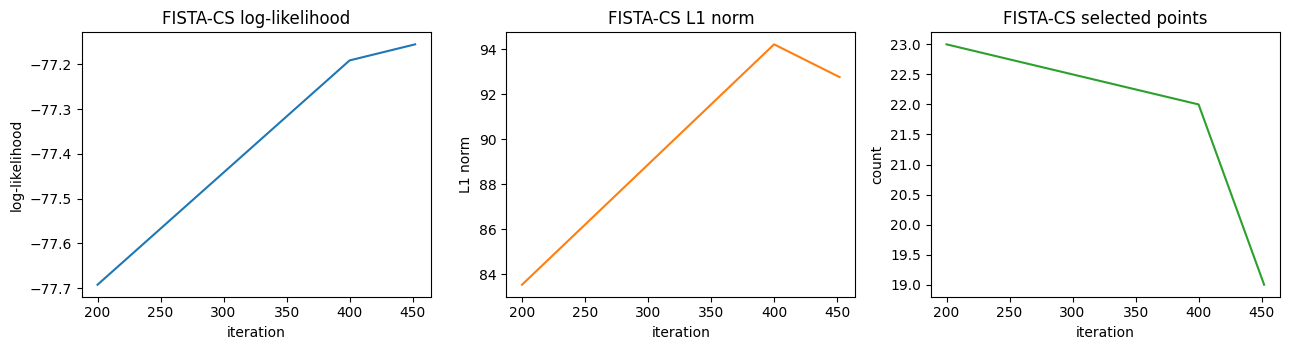

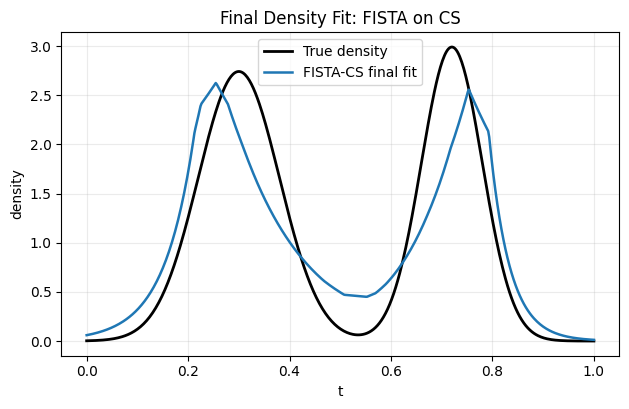

In [4]:
def history_df_from_results(results_dict: dict) -> pd.DataFrame:
    hist = results_dict.get("optimization_history", [])
    if len(hist) == 0:
        return pd.DataFrame(
            {
                "iteration": pd.Series(dtype="int64"),
                "log_likelihood": pd.Series(dtype="float64"),
                "l1_norm": pd.Series(dtype="float64"),
                "n_selected_points": pd.Series(dtype="int64"),
            }
        )
    return pd.DataFrame(hist)


# FISTA on current-status data
fista_cs_diag = IntervalCensoredFISTAEstimator(
    lam=float(fista_cs_cv_result.best_params["lam"]),
    basis_order=int(fista_cs_cv_result.best_params["basis_order"]),
    n_iterations=10000,
    tol=1e-6,
    ll_change_tol=1e-4,
    n_grid_points=260,
    initial_step=1.0,
    max_step=1.0,
    history_every=200,
)
fista_cs_diag.fit(cs_df, knot_strategy="turnbull")

fista_cs_diag_res = fista_cs_diag.get_results()
fista_cs_hist = history_df_from_results(fista_cs_diag_res)

print(
    {
        "model": "FISTA-CS",
        "converged": fista_cs_diag_res["converged"],
        "n_iterations_run": fista_cs_diag_res["n_iterations_run"],
        "basis_order": fista_cs_cv_result.best_params["basis_order"],
        "lam": fista_cs_cv_result.best_params["lam"],
    }
)

fista_cs_hist

if not fista_cs_hist.empty:
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
    axes[0].plot(fista_cs_hist["iteration"], fista_cs_hist["log_likelihood"], color="tab:blue")
    axes[0].set_title("FISTA-CS log-likelihood")
    axes[0].set_xlabel("iteration")
    axes[0].set_ylabel("log-likelihood")

    axes[1].plot(fista_cs_hist["iteration"], fista_cs_hist["l1_norm"], color="tab:orange")
    axes[1].set_title("FISTA-CS L1 norm")
    axes[1].set_xlabel("iteration")
    axes[1].set_ylabel("L1 norm")

    axes[2].plot(fista_cs_hist["iteration"], fista_cs_hist["n_selected_points"], color="tab:green")
    axes[2].set_title("FISTA-CS selected points")
    axes[2].set_xlabel("iteration")
    axes[2].set_ylabel("count")

    plt.tight_layout()
    plt.show()

# Final fit shape (CS)
grid_fit = np.linspace(0.0, 1.0, 500)
true_fit = sampler.compute_density(grid_fit)
est_fit = fista_cs_diag.get_density_at_points(grid_fit)

plt.figure(figsize=(7.2, 4.2))
plt.plot(grid_fit, true_fit, "k-", lw=2, label="True density")
plt.plot(grid_fit, est_fit, color="tab:blue", lw=1.8, label="FISTA-CS final fit")
plt.title("Final Density Fit: FISTA on CS")
plt.xlabel("t")
plt.ylabel("density")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

{'model': 'PGD-CS', 'converged': True, 'n_iterations_run': 12808, 'basis_order': 2, 'norm_constraint': 10.435109827473802}


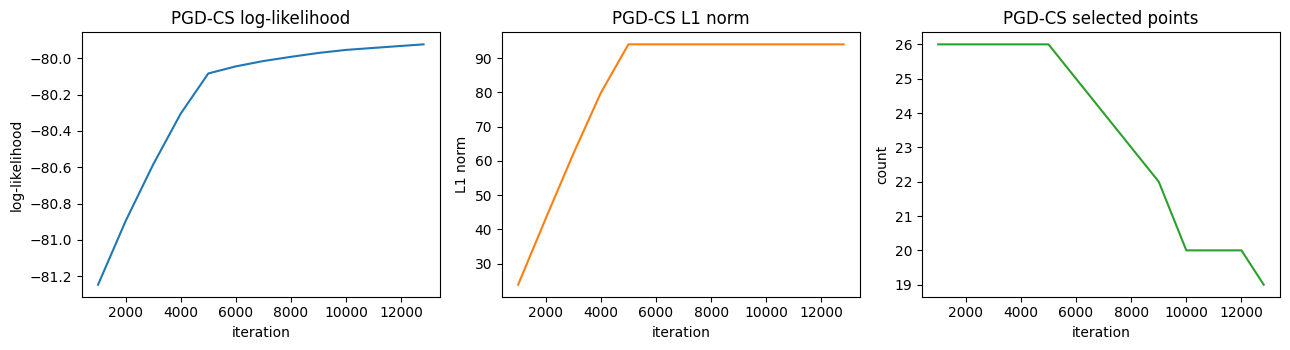

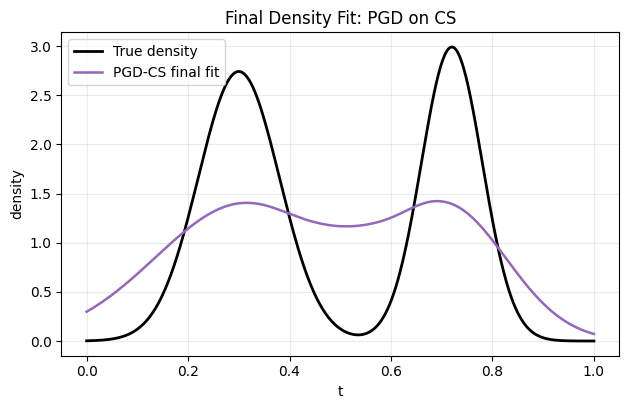

In [5]:
# Projected-GD on current-status data
pgd_cs_diag = IntervalCensoredProjectedGDEstimator(
    # norm_constraint=float(pgd_cs_cv_result.best_params["norm_constraint"]),
    norm_constraint=94,
    basis_order=int(pgd_cs_cv_result.best_params["basis_order"]),
    learning_rate=0.05,
    use_nesterov=True,
    n_iterations=300000,
    tol=1e-6,
    ll_change_tol=1e-5,
    n_grid_points=260,
    history_every=1000,
)
pgd_cs_diag.fit(cs_df, knot_strategy="turnbull")

pgd_cs_diag_res = pgd_cs_diag.get_results()
pgd_cs_hist = history_df_from_results(pgd_cs_diag_res)

print(
    {
        "model": "PGD-CS",
        "converged": pgd_cs_diag_res["converged"],
        "n_iterations_run": pgd_cs_diag_res["n_iterations_run"],
        "basis_order": pgd_cs_cv_result.best_params["basis_order"],
        "norm_constraint": pgd_cs_cv_result.best_params["norm_constraint"],
    }
)

pgd_cs_hist

if not pgd_cs_hist.empty:
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
    axes[0].plot(pgd_cs_hist["iteration"], pgd_cs_hist["log_likelihood"], color="tab:blue")
    axes[0].set_title("PGD-CS log-likelihood")
    axes[0].set_xlabel("iteration")
    axes[0].set_ylabel("log-likelihood")

    axes[1].plot(pgd_cs_hist["iteration"], pgd_cs_hist["l1_norm"], color="tab:orange")
    axes[1].set_title("PGD-CS L1 norm")
    axes[1].set_xlabel("iteration")
    axes[1].set_ylabel("L1 norm")

    axes[2].plot(pgd_cs_hist["iteration"], pgd_cs_hist["n_selected_points"], color="tab:green")
    axes[2].set_title("PGD-CS selected points")
    axes[2].set_xlabel("iteration")
    axes[2].set_ylabel("count")

    plt.tight_layout()
    plt.show()

# Final fit shape (CS)
grid_fit = np.linspace(0.0, 1.0, 500)
true_fit = sampler.compute_density(grid_fit)
est_fit = pgd_cs_diag.get_density_at_points(grid_fit)

plt.figure(figsize=(7.2, 4.2))
plt.plot(grid_fit, true_fit, "k-", lw=2, label="True density")
plt.plot(grid_fit, est_fit, color="tab:purple", lw=1.8, label="PGD-CS final fit")
plt.title("Final Density Fit: PGD on CS")
plt.xlabel("t")
plt.ylabel("density")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## CV Log-Likelihood Shape vs L1 Constraint `M`

This section evaluates how the CS CV incomplete log-likelihood changes as the projected-GD L1 constraint radius `M` varies.

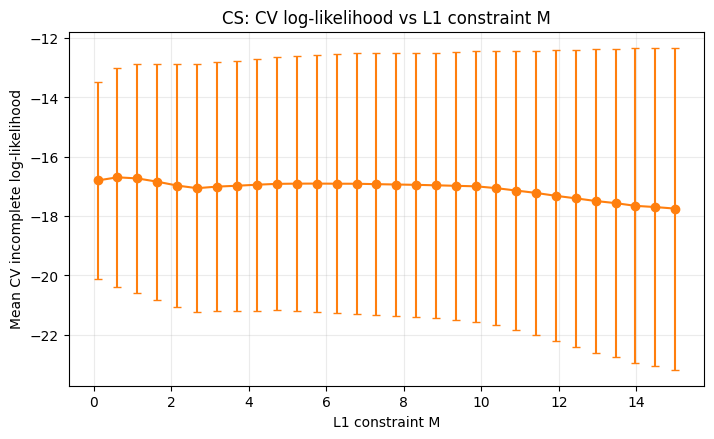

In [6]:
# Fix basis order to 0 for this shape analysis.
basis_order_for_shape = 0

# Grid of L1 constraints (M)
M_grid = np.unique(np.concatenate([np.linspace(0.1, 15.0, 30)]))


def compute_shape_curve(df: pd.DataFrame, *, m_grid: np.ndarray, random_state: int = 42) -> pd.DataFrame:
    kf = KFold(n_splits=5, shuffle=True, random_state=random_state)
    rows = []

    for M in m_grid:
        fold_ll = []
        for tr_idx, va_idx in kf.split(df):
            train_df = df.iloc[tr_idx].reset_index(drop=True)
            val_df = df.iloc[va_idx].reset_index(drop=True)

            est = IntervalCensoredProjectedGDEstimator(
                norm_constraint=float(M),
                basis_order=basis_order_for_shape,
                learning_rate=0.05,
                use_nesterov=True,
                n_iterations=10000,
                tol=1e-6,
                ll_change_tol=1e-4,
                n_grid_points=300,
            )
            est.fit(train_df, knot_strategy="turnbull")
            fold_ll.append(incomplete_loglik_interval(est, val_df, L_col="L", R_col="R"))

        rows.append(
            {
                "M": float(M),
                "cv_ll_mean": float(np.mean(fold_ll)),
                "cv_ll_sd": float(np.std(fold_ll, ddof=1)) if len(fold_ll) > 1 else 0.0,
            }
        )

    return pd.DataFrame(rows).sort_values("M").reset_index(drop=True)


shape_df_cs = compute_shape_curve(cs_df, m_grid=M_grid, random_state=42)
shape_df_cs.head()

plt.figure(figsize=(8.2, 4.6))
plt.errorbar(
    shape_df_cs["M"],
    shape_df_cs["cv_ll_mean"],
    yerr=shape_df_cs["cv_ll_sd"],
    fmt="o-",
    capsize=3,
    color="tab:orange",
)
plt.xlabel("L1 constraint M")
plt.ylabel("Mean CV incomplete log-likelihood")
plt.title("CS: CV log-likelihood vs L1 constraint M")
plt.grid(alpha=0.25)
plt.show()

CS global-max M: 0.613793, CVLL=-16.694614, converged=True (iters=43)
CS local-max  M: 5.75172, CVLL=-16.906092, converged=True (iters=271)


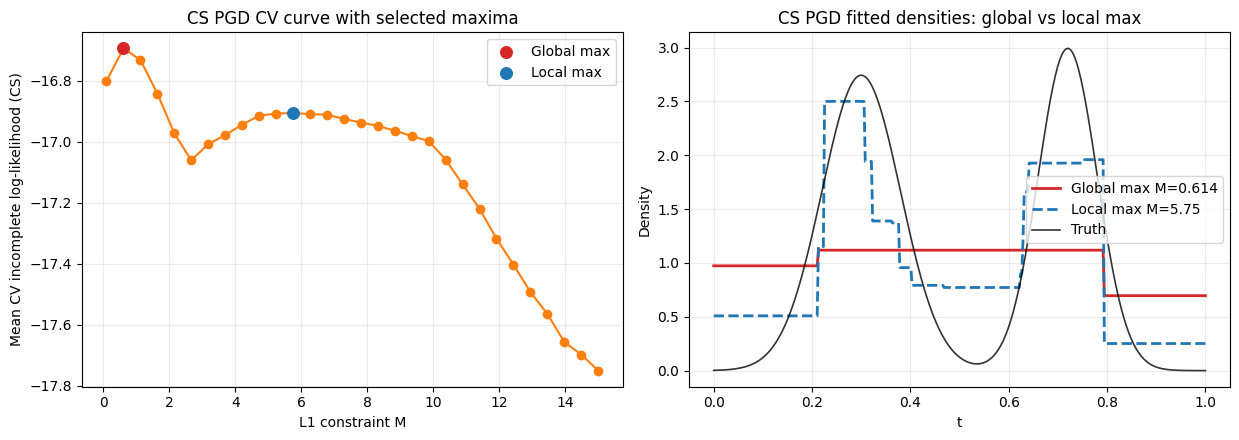

/var/folders/60/glgsl4b52js81mblbw2ymvlm0000gn/T/ipykernel_49910/3169718744.py:87: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mass = float(np.trapz(d, x))
/var/folders/60/glgsl4b52js81mblbw2ymvlm0000gn/T/ipykernel_49910/3169718744.py:101: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(p_ * np.log(p_ / q_), x))
/var/folders/60/glgsl4b52js81mblbw2ymvlm0000gn/T/ipykernel_49910/3169718744.py:130: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  "L1 density error": float(np.trapz(np.abs(f_true_m - f_global_m), x_eval_m)),
/var/folders/60/glgsl4b52js81mblbw2ymvlm0000gn/T/ipykernel_49910/3169718744.py:131: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical inte

,model,M,fitted L1 norm,n selected knots,KL density (truth || est),KL survival (truth || est),L1 density error,L1 survival error
0,Global max M=0.6138,0.613793,0.613793,2,0.474853,0.026926,0.824629,0.066145
1,Local max M=5.752,5.751724,5.751724,15,0.199643,0.017433,0.441730,0.030950


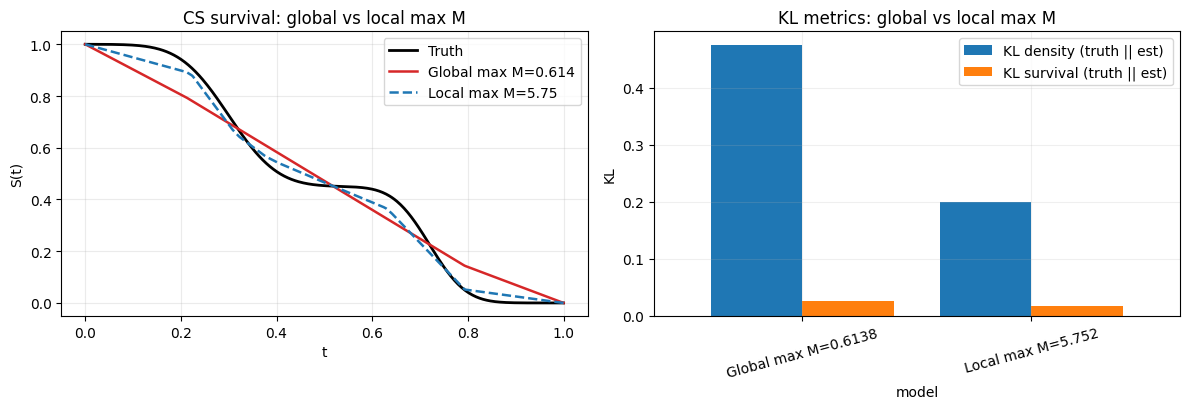

In [7]:
# Compare CS fits at global-max vs local-max M (from PGD CV curve)

x_cs_m = shape_df_cs["M"].to_numpy(dtype=float)
y_cs_m = shape_df_cs["cv_ll_mean"].to_numpy(dtype=float)

global_idx_cs_m = int(np.nanargmax(y_cs_m))
local_peak_idxs_cs_m = [
    i for i in range(1, len(y_cs_m) - 1) if (y_cs_m[i] > y_cs_m[i - 1]) and (y_cs_m[i] > y_cs_m[i + 1])
]

local_peak_idxs_cs_m = [i for i in local_peak_idxs_cs_m if i != global_idx_cs_m]
if local_peak_idxs_cs_m:
    local_idx_cs_m = max(local_peak_idxs_cs_m, key=lambda i: y_cs_m[i])
else:
    order_cs_m = np.argsort(y_cs_m)[::-1]
    local_idx_cs_m = int(order_cs_m[1]) if len(order_cs_m) > 1 else global_idx_cs_m

m_global_cs = float(x_cs_m[global_idx_cs_m])
m_local_cs = float(x_cs_m[local_idx_cs_m])


def fit_pgd_cs_at_m(m_val: float):
    est = IntervalCensoredProjectedGDEstimator(
        norm_constraint=float(m_val),
        basis_order=basis_order_for_shape,
        learning_rate=0.05,
        use_nesterov=True,
        n_iterations=10000,
        tol=1e-6,
        ll_change_tol=1e-4,
        n_grid_points=300,
    )
    est.fit(cs_df, knot_strategy="turnbull")
    return est


est_cs_global_m = fit_pgd_cs_at_m(m_global_cs)
est_cs_local_m = fit_pgd_cs_at_m(m_local_cs)

res_cs_global_m = est_cs_global_m.get_results()
res_cs_local_m = est_cs_local_m.get_results()

print(
    f"CS global-max M: {m_global_cs:.6g}, CVLL={y_cs_m[global_idx_cs_m]:.6f}, "
    f"converged={res_cs_global_m['converged']} (iters={res_cs_global_m['n_iterations_run']})"
)
print(
    f"CS local-max  M: {m_local_cs:.6g}, CVLL={y_cs_m[local_idx_cs_m]:.6f}, "
    f"converged={res_cs_local_m['converged']} (iters={res_cs_local_m['n_iterations_run']})"
)

x_grid_cs_m = np.linspace(0.0, 1.0, 400)
dens_cs_global_m = np.asarray(est_cs_global_m.get_density_at_points(x_grid_cs_m), dtype=float)
dens_cs_local_m = np.asarray(est_cs_local_m.get_density_at_points(x_grid_cs_m), dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))

axes[0].plot(x_cs_m, y_cs_m, "o-", color="tab:orange", lw=1.5)
axes[0].scatter([m_global_cs], [y_cs_m[global_idx_cs_m]], color="tab:red", s=70, zorder=3, label="Global max")
axes[0].scatter([m_local_cs], [y_cs_m[local_idx_cs_m]], color="tab:blue", s=70, zorder=3, label="Local max")
axes[0].set_xlabel("L1 constraint M")
axes[0].set_ylabel("Mean CV incomplete log-likelihood (CS)")
axes[0].set_title("CS PGD CV curve with selected maxima")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(x_grid_cs_m, dens_cs_global_m, color="tab:red", lw=2.0, label=f"Global max M={m_global_cs:.3g}")
axes[1].plot(x_grid_cs_m, dens_cs_local_m, color="tab:blue", lw=2.0, ls="--", label=f"Local max M={m_local_cs:.3g}")
axes[1].plot(x_grid_cs_m, sampler.compute_density(x_grid_cs_m), color="black", lw=1.2, alpha=0.8, label="Truth")
axes[1].set_xlabel("t")
axes[1].set_ylabel("Density")
axes[1].set_title("CS PGD fitted densities: global vs local max")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

# Comparison metrics for M-global vs M-local fits

eps = 1e-12
x_eval_m = np.asarray(x_grid_cs_m, dtype=float)


def _normalize_density_m(d: np.ndarray, x: np.ndarray, eps_: float = 1e-12) -> np.ndarray:
    d = np.maximum(np.asarray(d, dtype=float), eps_)
    mass = float(np.trapz(d, x))
    return d / max(mass, eps_)


def _density_to_survival_m(d: np.ndarray, x: np.ndarray) -> np.ndarray:
    dx = np.diff(x)
    cdf = np.concatenate([[0.0], np.cumsum(0.5 * (d[:-1] + d[1:]) * dx)])
    cdf = np.clip(cdf / max(cdf[-1], eps), 0.0, 1.0)
    return 1.0 - cdf


def _kl_curve_m(p: np.ndarray, q: np.ndarray, x: np.ndarray, eps_: float = 1e-12) -> float:
    p_ = np.maximum(np.asarray(p, dtype=float), eps_)
    q_ = np.maximum(np.asarray(q, dtype=float), eps_)
    return float(np.trapz(p_ * np.log(p_ / q_), x))


def _fitted_l1_m(estimator_obj) -> float:
    res = estimator_obj.get_results()
    hist = res.get("optimization_history", [])
    if hist and np.isfinite(hist[-1].get("l1_norm", np.nan)):
        return float(hist[-1]["l1_norm"])
    hal_coeffs = np.asarray(res.get("hal_coeffs", []), dtype=float)
    return float(np.sum(np.abs(hal_coeffs))) if hal_coeffs.size > 0 else np.nan


f_true_m = _normalize_density_m(np.asarray(sampler.compute_density(x_eval_m), dtype=float), x_eval_m)
S_true_m = _density_to_survival_m(f_true_m, x_eval_m)

f_global_m = _normalize_density_m(dens_cs_global_m, x_eval_m)
f_local_m = _normalize_density_m(dens_cs_local_m, x_eval_m)
S_global_m = _density_to_survival_m(f_global_m, x_eval_m)
S_local_m = _density_to_survival_m(f_local_m, x_eval_m)

m_compare_df = pd.DataFrame(
    [
        {
            "model": f"Global max M={m_global_cs:.4g}",
            "M": float(m_global_cs),
            "fitted L1 norm": _fitted_l1_m(est_cs_global_m),
            "n selected knots": int(res_cs_global_m.get("n_selected_knots", np.nan)) if np.isfinite(res_cs_global_m.get("n_selected_knots", np.nan)) else np.nan,
            "KL density (truth || est)": _kl_curve_m(f_true_m, f_global_m, x_eval_m, eps),
            "KL survival (truth || est)": _kl_curve_m(S_true_m, S_global_m, x_eval_m, eps),
            "L1 density error": float(np.trapz(np.abs(f_true_m - f_global_m), x_eval_m)),
            "L1 survival error": float(np.trapz(np.abs(S_true_m - S_global_m), x_eval_m)),
        },
        {
            "model": f"Local max M={m_local_cs:.4g}",
            "M": float(m_local_cs),
            "fitted L1 norm": _fitted_l1_m(est_cs_local_m),
            "n selected knots": int(res_cs_local_m.get("n_selected_knots", np.nan)) if np.isfinite(res_cs_local_m.get("n_selected_knots", np.nan)) else np.nan,
            "KL density (truth || est)": _kl_curve_m(f_true_m, f_local_m, x_eval_m, eps),
            "KL survival (truth || est)": _kl_curve_m(S_true_m, S_local_m, x_eval_m, eps),
            "L1 density error": float(np.trapz(np.abs(f_true_m - f_local_m), x_eval_m)),
            "L1 survival error": float(np.trapz(np.abs(S_true_m - S_local_m), x_eval_m)),
        },
    ]
)

display(m_compare_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(x_eval_m, S_true_m, color="black", lw=2.0, label="Truth")
axes[0].plot(x_eval_m, S_global_m, color="tab:red", lw=1.8, label=f"Global max M={m_global_cs:.3g}")
axes[0].plot(x_eval_m, S_local_m, color="tab:blue", lw=1.8, ls="--", label=f"Local max M={m_local_cs:.3g}")
axes[0].set_title("CS survival: global vs local max M")
axes[0].set_xlabel("t")
axes[0].set_ylabel("S(t)")
axes[0].grid(alpha=0.25)
axes[0].legend()

bar_df = m_compare_df.set_index("model")[["KL density (truth || est)", "KL survival (truth || est)"]]
bar_df.plot(kind="bar", ax=axes[1], width=0.8)
axes[1].set_title("KL metrics: global vs local max M")
axes[1].set_ylabel("KL")
axes[1].tick_params(axis="x", rotation=15)
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

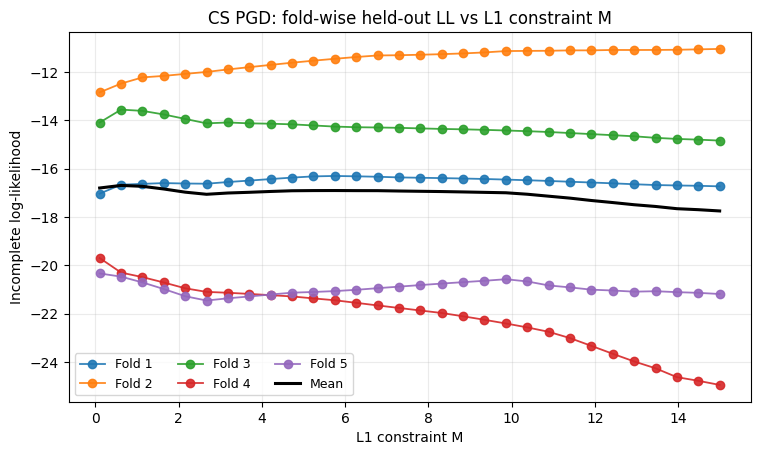

Nonconcave folds: 5/5
Per-fold nonconcave flags: {'Fold 1': True, 'Fold 2': True, 'Fold 3': True, 'Fold 4': True, 'Fold 5': True}
Max second difference per fold: {'Fold 1': 0.07795344472977916, 'Fold 2': 0.02369945858224476, 'Fold 3': 0.21986105341186857, 'Fold 4': 0.4151791693279776, 'Fold 5': 0.2702664793516938}


In [8]:
# Fold-wise held-out LL vs L1 constraint M for CS

kf_cs = KFold(n_splits=5, shuffle=True, random_state=42)
splits_cs = list(kf_cs.split(cs_df))

fold_ll_curves_cs = np.full((len(splits_cs), len(M_grid)), np.nan, dtype=float)

for j, M in enumerate(M_grid):
    for fold_id, (tr_idx, va_idx) in enumerate(splits_cs):
        train_df = cs_df.iloc[tr_idx].reset_index(drop=True)
        val_df = cs_df.iloc[va_idx].reset_index(drop=True)

        est = IntervalCensoredProjectedGDEstimator(
            norm_constraint=float(M),
            basis_order=basis_order_for_shape,
            learning_rate=0.05,
            use_nesterov=True,
            n_iterations=10000,
            tol=1e-6,
            ll_change_tol=1e-4,
            n_grid_points=300,
        )
        est.fit(train_df, knot_strategy="turnbull")

        fold_ll_curves_cs[fold_id, j] = float(
            incomplete_loglik_interval(est, val_df, L_col="L", R_col="R")
        )

plt.figure(figsize=(8.8, 4.8))
for fold_id in range(fold_ll_curves_cs.shape[0]):
    plt.plot(M_grid, fold_ll_curves_cs[fold_id], marker="o", lw=1.3, alpha=0.9, label=f"Fold {fold_id + 1}")

plt.plot(M_grid, np.mean(fold_ll_curves_cs, axis=0), color="black", lw=2.2, label="Mean")
plt.xlabel("L1 constraint M")
plt.ylabel("Incomplete log-likelihood")
plt.title("CS PGD: fold-wise held-out LL vs L1 constraint M")
plt.grid(alpha=0.25)
plt.legend(ncol=3, fontsize=9)
plt.show()

# Concavity check on sampled grid: second difference <= 0 (within tolerance)
tol = 1e-8
second_diff_cs = np.diff(fold_ll_curves_cs, n=2, axis=1)
nonconcave_mask_cs = np.any(second_diff_cs > tol, axis=1)

n_nonconcave = int(np.sum(nonconcave_mask_cs))
n_total = int(fold_ll_curves_cs.shape[0])

print(f"Nonconcave folds: {n_nonconcave}/{n_total}")
print("Per-fold nonconcave flags:", {f"Fold {i + 1}": bool(nonconcave_mask_cs[i]) for i in range(n_total)})

max_second_diff_per_fold = np.max(second_diff_cs, axis=1)
print("Max second difference per fold:", {f"Fold {i + 1}": float(max_second_diff_per_fold[i]) for i in range(n_total)})

Using fixed M = 0.613793

=== Restart/Convergence Summary ===
Total runs: 60
Converged runs: 60/60
Convergence rate: 1.000

=== Regret Summary (best-train proxy vs local converged runs) ===
Comparisons: 55
Mean delta_train: 0.000903
Median delta_train: 0.000036
Mean delta_valid: 0.000336
Median delta_valid: 0.000754
Valid win rate (delta_valid >= 0): 0.764


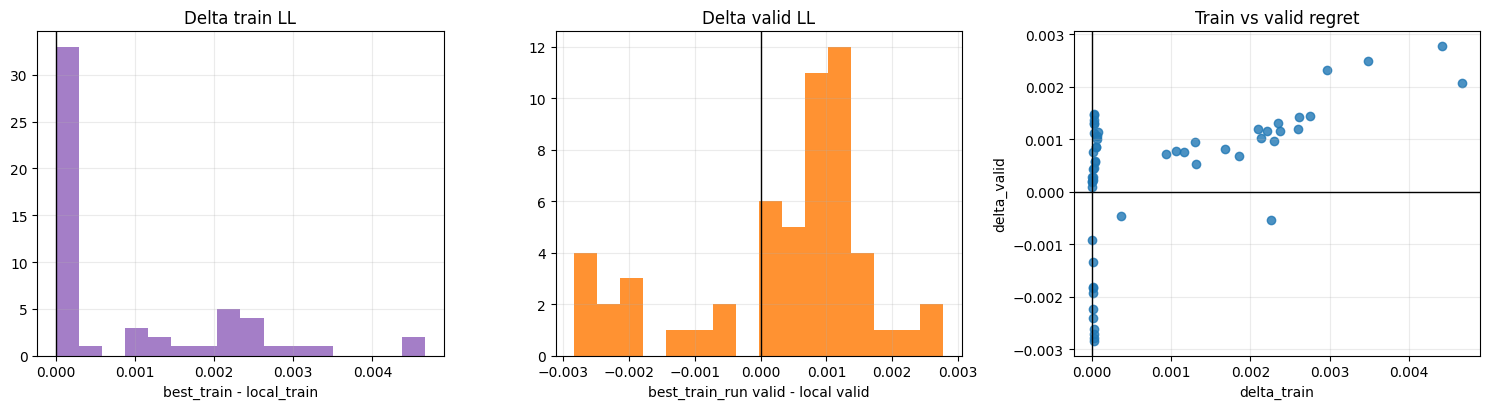


=== Density / KL Quality Summary ===
                               count      mean       std       min       25%  \
l1_density_diff_best_vs_local   55.0  0.000630  0.000589  0.000031  0.000228   
delta_kl_local_minus_best       55.0  0.000116  0.000196 -0.000102 -0.000007   

                                    50%       75%       max  
l1_density_diff_best_vs_local  0.000337  0.001086  0.002337  
delta_kl_local_minus_best      0.000017  0.000278  0.000680  


In [9]:
# Fixed-M local-vs-global (proxy) analysis for CS PGD via multi-restarts

M_fixed = float(m_global_cs) if "m_global_cs" in globals() else float(np.median(M_grid))
print(f"Using fixed M = {M_fixed:.6g}")

n_restarts = 12
warm_start_scale = 0.05
base_seed = 20260304

kf_fixed = KFold(n_splits=5, shuffle=True, random_state=42)
splits_fixed = list(kf_fixed.split(cs_df))

grid_eval = np.linspace(0.0, 1.0, 400)
true_density_eval = np.asarray(sampler.compute_density(grid_eval), dtype=float)

run_rows = []
regret_rows = []
quality_rows = []

for fold_id, (tr_idx, va_idx) in enumerate(splits_fixed, start=1):
    train_df = cs_df.iloc[tr_idx].reset_index(drop=True)
    val_df = cs_df.iloc[va_idx].reset_index(drop=True)

    fold_runs = []
    theta_dim = None

    for r in range(n_restarts):
        rng = np.random.default_rng(base_seed + 1000 * fold_id + r)
        use_nesterov_r = bool(r % 2 == 0)

        warm_start = None
        if theta_dim is not None:
            warm_start = rng.normal(loc=0.0, scale=warm_start_scale, size=theta_dim)

        est = IntervalCensoredProjectedGDEstimator(
            norm_constraint=float(M_fixed),
            basis_order=basis_order_for_shape,
            learning_rate=0.05,
            use_nesterov=use_nesterov_r,
            n_iterations=10000,
            tol=1e-6,
            ll_change_tol=1e-4,
            n_grid_points=300,
        )

        fit_kwargs = {"knot_strategy": "turnbull"}
        if warm_start is not None:
            fit_kwargs["warm_start_theta"] = warm_start

        est.fit(train_df, **fit_kwargs)
        res = est.get_results()

        train_ll = float(incomplete_loglik_interval(est, train_df, L_col="L", R_col="R"))
        valid_ll = float(incomplete_loglik_interval(est, val_df, L_col="L", R_col="R"))

        theta_dim = int(est.theta_hat.size)

        row = {
            "fold": int(fold_id),
            "restart": int(r),
            "use_nesterov": bool(use_nesterov_r),
            "converged": bool(res["converged"]),
            "n_iterations_run": int(res["n_iterations_run"]),
            "train_ll": float(train_ll),
            "valid_ll": float(valid_ll),
            "estimator": est,
        }
        fold_runs.append(row)
        run_rows.append({k: v for k, v in row.items() if k != "estimator"})

    converged_runs = [rr for rr in fold_runs if rr["converged"]]
    if len(converged_runs) < 2:
        print(f"Fold {fold_id}: fewer than 2 converged runs; skipping regret comparison")
        continue

    best_run = max(converged_runs, key=lambda z: z["train_ll"])
    dens_best = np.asarray(best_run["estimator"].get_density_at_points(grid_eval), dtype=float)

    for rr in converged_runs:
        if rr["restart"] == best_run["restart"]:
            continue

        delta_train = float(best_run["train_ll"] - rr["train_ll"])
        delta_valid = float(best_run["valid_ll"] - rr["valid_ll"])

        regret_rows.append(
            {
                "fold": int(fold_id),
                "best_restart": int(best_run["restart"]),
                "local_restart": int(rr["restart"]),
                "delta_train": delta_train,
                "delta_valid": delta_valid,
                "valid_win": bool(delta_valid >= 0.0),
            }
        )

        dens_local = np.asarray(rr["estimator"].get_density_at_points(grid_eval), dtype=float)
        l1_diff = float(np.mean(np.abs(dens_best - dens_local)))

        eps = 1e-12
        kl_best = float(
            np.trapezoid(
                true_density_eval * np.log(np.maximum(true_density_eval, eps) / np.maximum(dens_best, eps)),
                grid_eval,
            )
        )
        kl_local = float(
            np.trapezoid(
                true_density_eval * np.log(np.maximum(true_density_eval, eps) / np.maximum(dens_local, eps)),
                grid_eval,
            )
        )

        quality_rows.append(
            {
                "fold": int(fold_id),
                "local_restart": int(rr["restart"]),
                "l1_density_diff_best_vs_local": l1_diff,
                "kl_best": kl_best,
                "kl_local": kl_local,
                "delta_kl_local_minus_best": float(kl_local - kl_best),
            }
        )

run_df = pd.DataFrame(run_rows)
regret_df = pd.DataFrame(regret_rows)
quality_df = pd.DataFrame(quality_rows)

print("\n=== Restart/Convergence Summary ===")
print(f"Total runs: {len(run_df)}")
print(f"Converged runs: {int(run_df['converged'].sum())}/{len(run_df)}")
print(f"Convergence rate: {float(run_df['converged'].mean()):.3f}")

if len(regret_df) == 0:
    print("\nNo regret comparisons available (not enough converged runs per fold).")
else:
    print("\n=== Regret Summary (best-train proxy vs local converged runs) ===")
    print(f"Comparisons: {len(regret_df)}")
    print(f"Mean delta_train: {regret_df['delta_train'].mean():.6f}")
    print(f"Median delta_train: {regret_df['delta_train'].median():.6f}")
    print(f"Mean delta_valid: {regret_df['delta_valid'].mean():.6f}")
    print(f"Median delta_valid: {regret_df['delta_valid'].median():.6f}")
    print(f"Valid win rate (delta_valid >= 0): {regret_df['valid_win'].mean():.3f}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

    axes[0].hist(regret_df["delta_train"], bins=16, color="tab:purple", alpha=0.85)
    axes[0].axvline(0.0, color="black", lw=1.0)
    axes[0].set_title("Delta train LL")
    axes[0].set_xlabel("best_train - local_train")
    axes[0].grid(alpha=0.25)

    axes[1].hist(regret_df["delta_valid"], bins=16, color="tab:orange", alpha=0.85)
    axes[1].axvline(0.0, color="black", lw=1.0)
    axes[1].set_title("Delta valid LL")
    axes[1].set_xlabel("best_train_run valid - local valid")
    axes[1].grid(alpha=0.25)

    axes[2].scatter(regret_df["delta_train"], regret_df["delta_valid"], alpha=0.8, color="tab:blue")
    axes[2].axhline(0.0, color="black", lw=1.0)
    axes[2].axvline(0.0, color="black", lw=1.0)
    axes[2].set_title("Train vs valid regret")
    axes[2].set_xlabel("delta_train")
    axes[2].set_ylabel("delta_valid")
    axes[2].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

if len(quality_df) > 0:
    print("\n=== Density / KL Quality Summary ===")
    print(quality_df[["l1_density_diff_best_vs_local", "delta_kl_local_minus_best"]].describe().T)

## CV Log-Likelihood Shape vs FISTA `lambda`

This section evaluates CS CV incomplete log-likelihood across a grid of FISTA regularization values `lambda`.

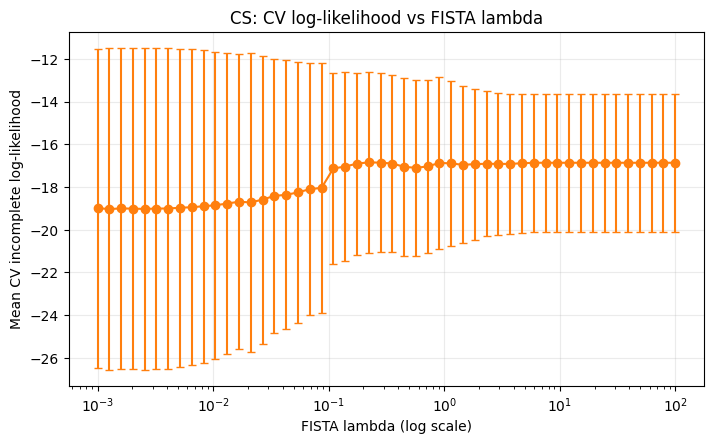

In [10]:
lambda_grid = np.geomspace(1e-3, 1e2, 50)
# Fix basis order to 0 for this shape analysis.
basis_order_for_lambda = 0


def compute_lambda_curve(df: pd.DataFrame, *, lam_grid: np.ndarray, random_state: int = 42) -> pd.DataFrame:
    kf = KFold(n_splits=5, shuffle=True, random_state=random_state)
    rows_lam = []

    for lam in lam_grid:
        fold_ll = []
        for tr_idx, va_idx in kf.split(df):
            train_df = df.iloc[tr_idx].reset_index(drop=True)
            val_df = df.iloc[va_idx].reset_index(drop=True)

            est = IntervalCensoredFISTAEstimator(
                lam=float(lam),
                basis_order=basis_order_for_lambda,
                n_iterations=2000,
                tol=1e-6,
                ll_change_tol=1e-3,
                n_grid_points=300,
                initial_step=1.0,
                max_step=1.0,
            )
            est.fit(train_df, knot_strategy="turnbull")
            fold_ll.append(incomplete_loglik_interval(est, val_df, L_col="L", R_col="R"))

        rows_lam.append(
            {
                "lambda": float(lam),
                "cv_ll_mean": float(np.mean(fold_ll)),
                "cv_ll_sd": float(np.std(fold_ll, ddof=1)) if len(fold_ll) > 1 else 0.0,
            }
        )

    return pd.DataFrame(rows_lam).sort_values("lambda").reset_index(drop=True)


shape_lam_df_cs = compute_lambda_curve(cs_df, lam_grid=lambda_grid, random_state=42)
shape_lam_df_cs.head()

plt.figure(figsize=(8.2, 4.6))
plt.errorbar(
    shape_lam_df_cs["lambda"],
    shape_lam_df_cs["cv_ll_mean"],
    yerr=shape_lam_df_cs["cv_ll_sd"],
    fmt="o-",
    capsize=3,
    color="tab:orange",
)
plt.xscale("log")
plt.xlabel("FISTA lambda (log scale)")
plt.ylabel("Mean CV incomplete log-likelihood")
plt.title("CS: CV log-likelihood vs FISTA lambda")
plt.grid(alpha=0.25)
plt.show()

CS global-max lambda: 0.2223, CVLL=-16.848133
CS local-max  lambda: 0.910298, CVLL=-16.871164


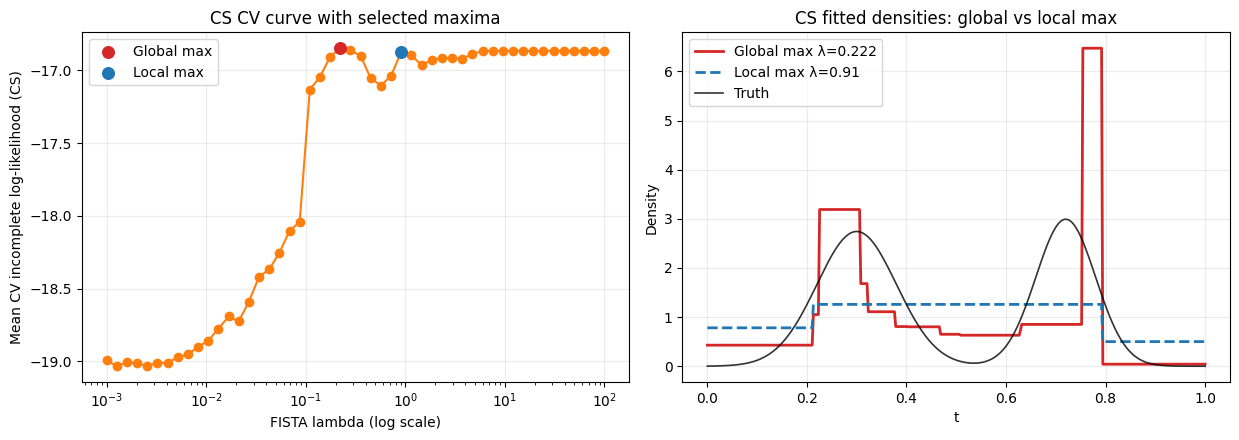

In [11]:
# Compare CS fits at global-max vs local-max lambda (from FISTA CV curve)

x_cs = shape_lam_df_cs["lambda"].to_numpy(dtype=float)
y_cs = shape_lam_df_cs["cv_ll_mean"].to_numpy(dtype=float)

global_idx = int(np.nanargmax(y_cs))
local_peak_idxs = [
    i for i in range(1, len(y_cs) - 1) if (y_cs[i] > y_cs[i - 1]) and (y_cs[i] > y_cs[i + 1])
]

local_peak_idxs = [i for i in local_peak_idxs if i != global_idx]
if local_peak_idxs:
    local_idx = max(local_peak_idxs, key=lambda i: y_cs[i])
else:
    order = np.argsort(y_cs)[::-1]
    local_idx = int(order[1]) if len(order) > 1 else global_idx

lam_global = float(x_cs[global_idx])
lam_local = float(x_cs[local_idx])

print(f"CS global-max lambda: {lam_global:.6g}, CVLL={y_cs[global_idx]:.6f}")
print(f"CS local-max  lambda: {lam_local:.6g}, CVLL={y_cs[local_idx]:.6f}")


def fit_fista_cs_at_lambda(lam: float):
    est = IntervalCensoredFISTAEstimator(
        lam=float(lam),
        basis_order=basis_order_for_lambda,
        n_iterations=2000,
        tol=1e-6,
        ll_change_tol=1e-3,
        n_grid_points=300,
        initial_step=1.0,
        max_step=1.0,
    )
    est.fit(cs_df, knot_strategy="turnbull")
    return est


est_cs_global = fit_fista_cs_at_lambda(lam_global)
est_cs_local = fit_fista_cs_at_lambda(lam_local)

x_grid = np.linspace(0.0, 1.0, 400)
dens_cs_global = np.asarray(est_cs_global.get_density_at_points(x_grid), dtype=float)
dens_cs_local = np.asarray(est_cs_local.get_density_at_points(x_grid), dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))

axes[0].plot(x_cs, y_cs, "o-", color="tab:orange", lw=1.5)
axes[0].scatter([lam_global], [y_cs[global_idx]], color="tab:red", s=70, zorder=3, label="Global max")
axes[0].scatter([lam_local], [y_cs[local_idx]], color="tab:blue", s=70, zorder=3, label="Local max")
axes[0].set_xscale("log")
axes[0].set_xlabel("FISTA lambda (log scale)")
axes[0].set_ylabel("Mean CV incomplete log-likelihood (CS)")
axes[0].set_title("CS CV curve with selected maxima")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(x_grid, dens_cs_global, color="tab:red", lw=2.0, label=f"Global max λ={lam_global:.3g}")
axes[1].plot(x_grid, dens_cs_local, color="tab:blue", lw=2.0, ls="--", label=f"Local max λ={lam_local:.3g}")
axes[1].plot(x_grid, sampler.compute_density(x_grid), color="black", lw=1.2, alpha=0.8, label="Truth")
axes[1].set_xlabel("t")
axes[1].set_ylabel("Density")
axes[1].set_title("CS fitted densities: global vs local max")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

## KL Metrics: Density and Survival vs Truth

This section adds quantitative comparisons against the true data-generating distribution for the two FISTA-CS fits selected from the CV-lambda landscape:

- Density KL: `KL(f_true || f_est)`
- Survival-curve KL: `\int S_true(t) log(S_true(t) / S_est(t)) dt`

Both are reported on the same evaluation grid used in the previous section.

/var/folders/60/glgsl4b52js81mblbw2ymvlm0000gn/T/ipykernel_49910/4179837833.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mass = float(np.trapz(d, x))
/var/folders/60/glgsl4b52js81mblbw2ymvlm0000gn/T/ipykernel_49910/4179837833.py:30: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(p_ * np.log(p_ / q_), x))
/var/folders/60/glgsl4b52js81mblbw2ymvlm0000gn/T/ipykernel_49910/4179837833.py:83: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  "L1 density error": float(np.trapz(np.abs(f_true - f_est), x_eval)),
/var/folders/60/glgsl4b52js81mblbw2ymvlm0000gn/T/ipykernel_49910/4179837833.py:84: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration func

,model,fitted L1 norm,n selected knots,KL density (truth || est),KL survival (truth || est),L1 density error,L1 survival error
0,Local max lambda=0.9103,1.398180,2,0.404761,0.022509,0.754045,0.058120
1,Global max lambda=0.2223,11.003785,12,0.442886,0.013610,0.738914,0.029174


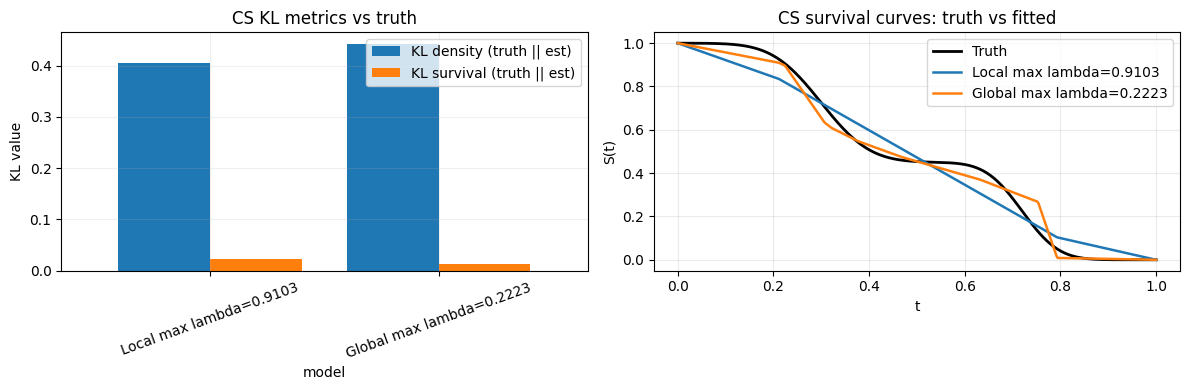

In [12]:
# KL metrics for density and survival (truth vs fitted)
# Reuse variables from the previous lambda-comparison cell.

eps = 1e-12
x_eval = np.asarray(x_grid, dtype=float)
f_true_raw = np.asarray(sampler.compute_density(x_eval), dtype=float)


def _normalize_density(d: np.ndarray, x: np.ndarray, eps_: float = 1e-12) -> np.ndarray:
    d = np.maximum(np.asarray(d, dtype=float), eps_)
    mass = float(np.trapz(d, x))
    if mass <= 0.0:
        raise ValueError("Estimated density has non-positive mass on evaluation grid.")
    return d / mass


def _density_to_survival(d: np.ndarray, x: np.ndarray) -> np.ndarray:
    # Build CDF by trapezoidal cumulative integration, then convert to survival.
    dx = np.diff(x)
    cdf = np.concatenate(
        [[0.0], np.cumsum(0.5 * (d[:-1] + d[1:]) * dx)]
    )
    cdf = np.clip(cdf / max(cdf[-1], eps), 0.0, 1.0)
    return 1.0 - cdf


def _kl_curve(p: np.ndarray, q: np.ndarray, x: np.ndarray, eps_: float = 1e-12) -> float:
    p_ = np.maximum(np.asarray(p, dtype=float), eps_)
    q_ = np.maximum(np.asarray(q, dtype=float), eps_)
    return float(np.trapz(p_ * np.log(p_ / q_), x))


f_true = _normalize_density(f_true_raw, x_eval)
S_true = _density_to_survival(f_true, x_eval)

candidate_models = {
    f"Global max lambda={lam_global:.4g}": {
        "density": dens_cs_global,
        "estimator": est_cs_global,
    },
    f"Local max lambda={lam_local:.4g}": {
        "density": dens_cs_local,
        "estimator": est_cs_local,
    },
}


def _final_l1_norm(estimator_obj) -> float:
    res = estimator_obj.get_results()

    # Preferred source: explicit optimization history trace.
    hist = res.get("optimization_history", [])
    if hist:
        last_l1 = hist[-1].get("l1_norm", np.nan)
        if np.isfinite(last_l1):
            return float(last_l1)

    # Robust fallback: L1 norm of HAL coefficients from final fitted model.
    # This matches the regularization quantity (excluding intercept/polynomial terms).
    hal_coeffs = np.asarray(res.get("hal_coeffs", []), dtype=float)
    if hal_coeffs.size > 0:
        return float(np.sum(np.abs(hal_coeffs)))

    return np.nan


rows = []
surv_curves = {"Truth": S_true}

for model_name, payload in candidate_models.items():
    f_est = _normalize_density(np.asarray(payload["density"], dtype=float), x_eval)
    S_est = _density_to_survival(f_est, x_eval)

    est_res = payload["estimator"].get_results()

    rows.append(
        {
            "model": model_name,
            "fitted L1 norm": _final_l1_norm(payload["estimator"]),
            "n selected knots": int(est_res.get("n_selected_knots", np.nan)) if np.isfinite(est_res.get("n_selected_knots", np.nan)) else np.nan,
            "KL density (truth || est)": _kl_curve(f_true, f_est, x_eval, eps),
            "KL survival (truth || est)": _kl_curve(S_true, S_est, x_eval, eps),
            "L1 density error": float(np.trapz(np.abs(f_true - f_est), x_eval)),
            "L1 survival error": float(np.trapz(np.abs(S_true - S_est), x_eval)),
        }
    )
    surv_curves[model_name] = S_est

cs_kl_metrics_df = pd.DataFrame(rows).sort_values("KL density (truth || est)").reset_index(drop=True)
display(cs_kl_metrics_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# KL summary bars
kl_plot_df = cs_kl_metrics_df.set_index("model")[[
    "KL density (truth || est)",
    "KL survival (truth || est)",
]]
kl_plot_df.plot(kind="bar", ax=axes[0], width=0.8)
axes[0].set_title("CS KL metrics vs truth")
axes[0].set_ylabel("KL value")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(alpha=0.2)

# Survival curves
axes[1].plot(x_eval, surv_curves["Truth"], color="black", lw=2.0, label="Truth")
for model_name in cs_kl_metrics_df["model"]:
    axes[1].plot(x_eval, surv_curves[model_name], lw=1.8, label=model_name)
axes[1].set_title("CS survival curves: truth vs fitted")
axes[1].set_xlabel("t")
axes[1].set_ylabel("S(t)")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()